### Implementation using Gillespie Algorithm

In [39]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Parameters: standard 1e-1, 1e-3, 0 [1e-3], 1e-2, 3; 200, 20
kn, ka, kd, kf, nc = 5e-2, 2e-3, 0, 1e-2, 3  # either dissociation OR fragmentation size should be zero (fragmentation incorporates dissociation as a special case)
tmax, jmax = 200, 20

lengths = np.arange(1, jmax + 1)
Mt = lambda f: np.dot(lengths, f[1:])
Pt = lambda f: np.sum(f[1:])

# initial conditions: standard m0 = 1e3, t = 0
m0, t = 1e3, 0

f = np.zeros(jmax + 1)  # index 0 is unused; polymer lengths run from 1..jmax (or rather nc...jmax)!
ft, tt, Mtt, Ptt = [np.copy(f)], [t], [Mt(f)], [Pt(f)]
assoc_rates, dissoc_rates, fragm_rates = np.zeros_like(f), np.zeros_like(f), np.zeros_like(f)

# run Gillespie
total_rate = 1
while t <= tmax:
    # 1. update rates
    mt = m0 - Mt(f)
    nucl_rate = kn * (mt/m0)**nc  # nucleation rate (normalised)
    for j in range(nc, jmax): assoc_rates[j] = ka * mt * f[j]
    for j in range(nc + 1, jmax + 1):
        dissoc_rates[j] = kd * f[j]; fragm_rates[j] = kf * f[j] * (j - 1)
    total_rate = nucl_rate + np.sum(assoc_rates) + np.sum(dissoc_rates) + np.sum(fragm_rates)
    if total_rate <= 0:
        print('total_rate=', total_rate)
        break

    # 2. time to next reaction
    rn1 = random.random()
    tau = -np.log(rn1) / total_rate
    # 3. find which reaction will take place
    rn2 = random.random()
    done = False

    if rn2 < nucl_rate / total_rate:
        f[nc] += 1
        done = True
    else:
        current_rate = nucl_rate
        for jj in range(nc, jmax):  # association
            current_rate += assoc_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj+1] += 1; f[jj] -= 1
                done = True
                break
        for jj in range(nc + 1, jmax + 1):  # dissociation
            current_rate += dissoc_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj] -= 1; f[jj - 1] += 1
                done = True
                break
        for jj in range(nc + 1, jmax + 1):  # fragmentation
            current_rate += fragm_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj] -= 1
                break_point = random.randint(1, jj - 1)
                if break_point < nc:  # if the break point is in the nucleation range, we just get monomers
                    if jj-break_point >= nc: f[jj-break_point] += 1
                elif break_point > jj - nc:
                    if break_point >= nc: f[break_point] += 1
                else:
                    f[jj - break_point] += 1
                    f[break_point] += 1
                done = True
                break

    # 4. advance in time with tau
    t += tau

    # save values for plotting
    ft.append(np.copy(f))
    Mtt.append(Mt(f))
    Ptt.append(Pt(f))
    tt.append(t)

ft, tt, Mtt, Ptt = np.array(ft), np.array(tt), np.array(Mtt), np.array(Ptt)
print(np.shape(ft), f'total_rate={total_rate}', tt[-1], Ptt[-1], Mtt[-1])

(3482, 21) total_rate=19.07400121945 200.0680482541015 223.0 972.0


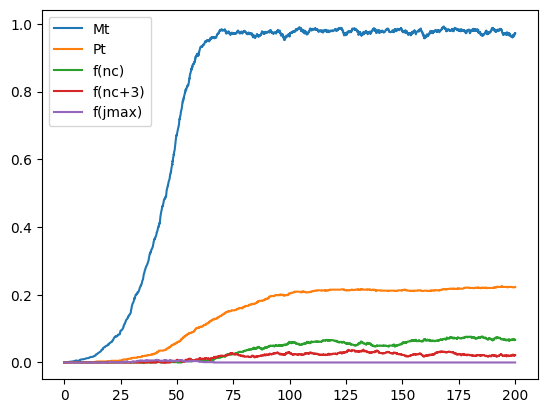

In [40]:
plt.plot(tt, Mtt/m0, label='Mt'); plt.plot(tt, Ptt / m0, label='Pt')  # how does M(t),P(t) look
plt.plot(tt, ft[:,nc]/m0, label='f(nc)'); plt.plot(tt, ft[:,nc+3]/m0, label='f(nc+3)') # how does f(nc) etc look
plt.plot(tt, ft[:,jmax]/m0, label='f(jmax)') # how does f(jmax) look
plt.legend()

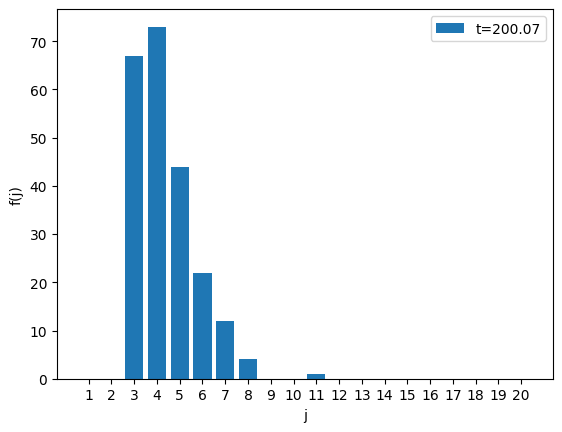

In [ ]:
# how does f(t,j) look at a given time point?
t_idx = -1  # index to look at!
plt.bar(lengths, ft[t_idx, 1:])
plt.xlabel('j'); plt.ylabel('f(j)')
plt.xticks(lengths); plt.xlabel('j'); plt.ylabel('f(j)')
plt.legend([f't={tt[t_idx]:0.2f}'])

3482

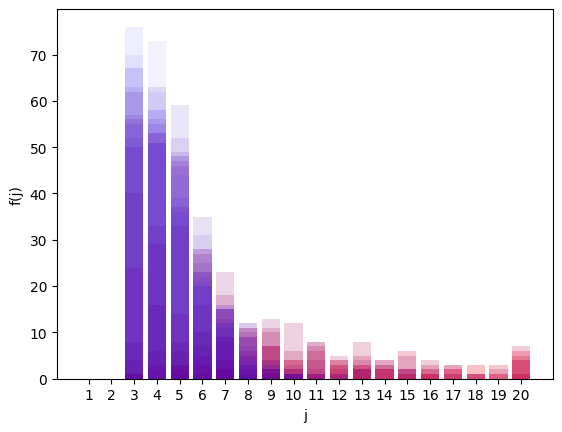

In [42]:
# combining all times (beginning red, end blue)
T = len(tt)
step = max(1, T // 20)
for i in range(1, T, step):
    plt.bar(lengths, ft[i, 1:], color = ((T - i) / T, 0, i / T), alpha=0.2*(1-i/T)+0.05)
plt.xticks(lengths); plt.xlabel('j'); plt.ylabel('f(j)'); T

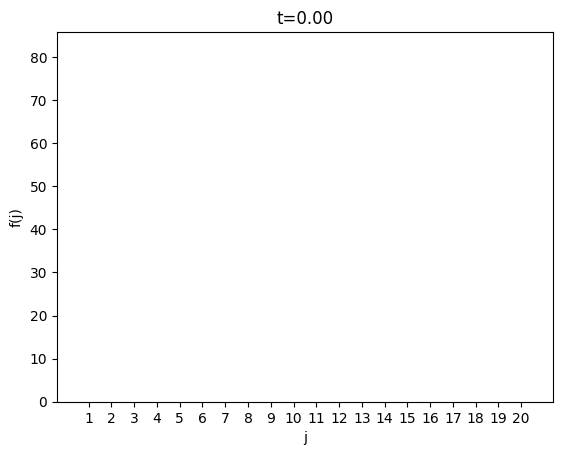

In [43]:
# make an animation showing the distribution at different times:
import matplotlib.animation as animation
fig, ax = plt.subplots()
def animate(i):
    ax.clear()
    ax.bar(lengths, ft[i, 1:], color = ((T - i) / T, 0, i / T))
    ax.set_ylim(0, np.max(ft) * 1.1)
    ax.set_xticks(lengths); ax.set_xlabel('j'); ax.set_ylabel('f(j)')
    ax.set_title(f't={tt[i]:0.2f}')
step = max(1, T // 30)
ani = animation.FuncAnimation(fig, animate, frames=range(0, T, step), repeat=False)
ani.save('fragmentation_fun.gif', writer='pillow', fps=10)

### Results
- get the non-linear "kink" via fragmentation term (low nuceation, medium association & fragmentation)!
- qualitative behaviour over time (see animation): initially only a few nucleations which are subsequently "carried" upwards to maximum polymer length (accumulating at this size), until the rapid growth comes around and the max-size polymeres are broken down and we move towards the steady state which has almost no very big polymers but rather a lot of near-nucleation size ones?! -> that's kinda weird???